# 07 - Restaurant Clustering (PuneBite Analyzer)

**Objective:** segment rated restaurants using review volume, rating, price, polarization, and amenities, then compare clustering methods and profile each segment.
**Input:** `data/processed/restaurants_clean.csv`
**Output:** cluster profiles and `data/processed/restaurants_clusters.csv` (`url`, `cluster`, `cluster_name`)
**Syllabus link:** Unit VI (K-Means, hierarchical clustering, DBSCAN, Gaussian Mixture Models, PCA and density estimation).

Restaurants without ratings or with zero votes are excluded. The data has no coordinates, so these are behavioral/business segments, not map clusters.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "restaurants_clean.csv")
data = df.loc[df["rating"].notna() & (df["votes"] > 0)].copy()
data = data.dropna(subset=["cost_capped", "polarization_pct", "n_amenities"])
feature_cols = ["rating", "log_votes", "log_cost", "polarization_pct", "n_amenities"]
data["log_votes"] = np.log1p(data["votes"])
data["log_cost"] = np.log(data["cost_capped"].clip(lower=1))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[feature_cols])
print(f"Usable restaurants: {len(data):,} of {len(df):,}")
print(f"Rated mean: {data['rating'].mean():.3f}; median votes: {data['votes'].median():.0f}")
print("Standardized feature means (near zero):", np.round(X_scaled.mean(axis=0), 3))

Usable restaurants: 7,648 of 12,134
Rated mean: 3.436; median votes: 30
Standardized feature means (near zero): [ 0. -0.  0.  0.  0.]


,k,inertia,silhouette,elbow_distance
0,2,26526.386253,0.318338,0.000000
1,3,20894.796072,0.270207,0.170815
2,4,17097.348650,0.267166,0.257210
3,5,15589.396143,0.236221,0.238228
4,6,14344.414212,0.224800,0.207141
5,7,13318.758162,0.216364,0.165961
6,8,12452.828783,0.215840,0.117428
7,9,11775.546057,0.206848,0.060213
8,10,11163.387168,0.206856,0.000000


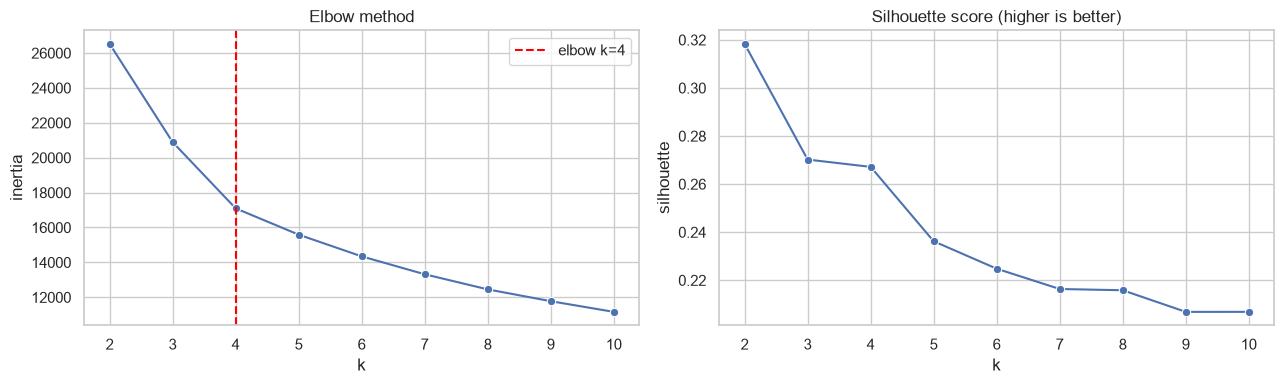

Selected k=4 from the maximum-distance elbow; silhouette independently prefers k=2 (0.318). The methods disagree, so use the elbow's more interpretable segmentation and report the trade-off.


In [2]:
k_values = range(2, 11)
inertias, silhouettes = [], []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=min(3000, len(data)), random_state=RANDOM_STATE))

normalized_k = np.linspace(0, 1, len(inertias))
normalized_inertia = (np.asarray(inertias) - min(inertias)) / (max(inertias) - min(inertias))
elbow_distance = np.abs(normalized_k + normalized_inertia - 1) / np.sqrt(2)
k_metrics = pd.DataFrame({"k": list(k_values), "inertia": inertias, "silhouette": silhouettes, "elbow_distance": elbow_distance})
display(k_metrics)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=k_metrics, x="k", y="inertia", marker="o", ax=axes[0])
elbow_k = int(k_metrics.loc[k_metrics["elbow_distance"].idxmax(), "k"])
axes[0].axvline(elbow_k, color="red", linestyle="--", label=f"elbow k={elbow_k}")
axes[0].legend()
axes[0].set_title("Elbow method")
sns.lineplot(data=k_metrics, x="k", y="silhouette", marker="o", ax=axes[1])
axes[1].set_title("Silhouette score (higher is better)")
plt.tight_layout()
plt.show()
silhouette_k = int(k_metrics.loc[k_metrics["silhouette"].idxmax(), "k"])
best_k = elbow_k
print(f"Selected k={best_k} from the maximum-distance elbow; silhouette independently prefers k={silhouette_k} ({k_metrics['silhouette'].max():.3f}). The methods disagree, so use the elbow's more interpretable segmentation and report the trade-off.")
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
data["cluster"] = kmeans.fit_predict(X_scaled)

,cluster_name,size,rating_mean,votes_median,cost_median,polarization_mean,amenities_mean,top_types,top_cuisines,top_localities
cluster,,,,,,,,,,
0,Premium dining,2320,3.76,99.0,450.0,18.59,3.60,"Quick Bites, Casual Dining, Café","North Indian, Chinese, Fast Food","Kothrud, Viman Nagar, Wakad"
1,Polarizing experiences,1854,3.05,19.0,400.0,45.85,3.30,"Quick Bites, Casual Dining, Takeaway","North Indian, Chinese, Fast Food","Hadapsar, Sinhgad Road, Kothrud"
2,High-volume crowd favorites,764,3.99,380.0,1300.0,15.21,8.91,"Casual Dining, Bar, Lounge","North Indian, Chinese, Continental","Baner, Viman Nagar, Hinjawadi"
3,Low-volume neighborhood venues,2710,3.27,11.0,400.0,6.12,2.88,"Quick Bites, Casual Dining, Takeaway","North Indian, Chinese, Fast Food","Kothrud, Wakad, Hadapsar"


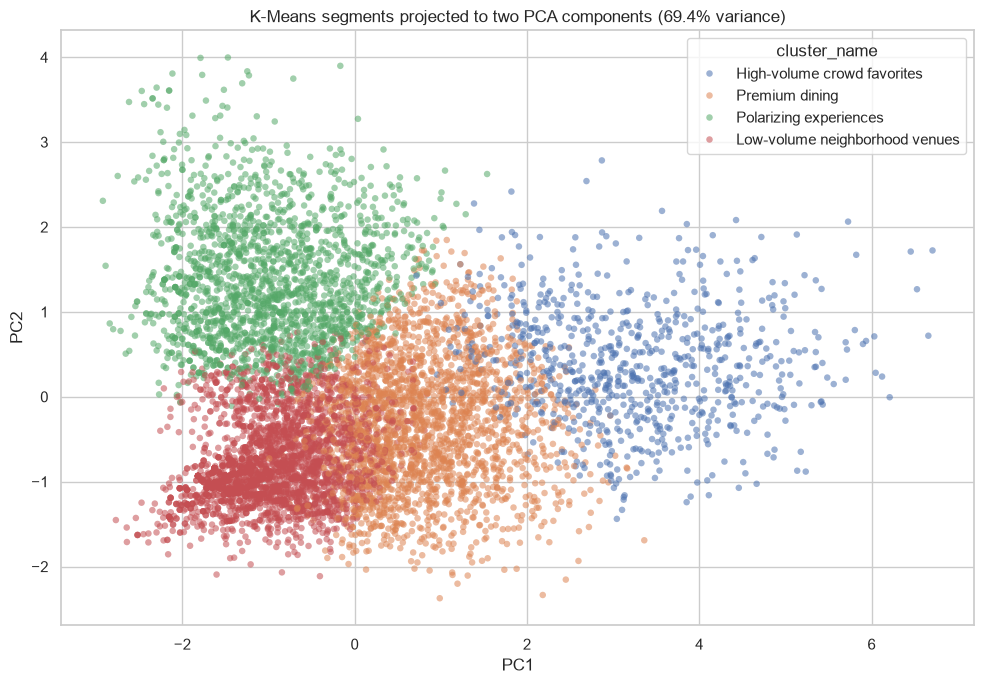

Saved 7,648 restaurant labels to A:\DSML\PuneBite\data\processed\restaurants_clusters.csv


In [3]:
profile = data.groupby("cluster").agg(
    size=("url", "size"), rating_mean=("rating", "mean"), votes_median=("votes", "median"),
    cost_median=("cost_capped", "median"), polarization_mean=("polarization_pct", "mean"),
    amenities_mean=("n_amenities", "mean"), log_votes_mean=("log_votes", "mean"),
    log_cost_mean=("log_cost", "mean"),
)
names = {}
remaining = set(profile.index)
gem_candidates = profile.loc[(profile["rating_mean"] >= data["rating"].mean()) & (profile["votes_median"] <= data["votes"].median())]
if not gem_candidates.empty:
    gem_cluster = int((gem_candidates["rating_mean"].rank(pct=True) - gem_candidates["log_votes_mean"].rank(pct=True)).idxmax())
    names[gem_cluster] = "High-rated, low-visibility candidates"
else:
    gem_cluster = int(profile.loc[list(remaining), "votes_median"].idxmin())
    names[gem_cluster] = "Low-volume neighborhood venues"
remaining.remove(gem_cluster)
for column, label in [("log_votes_mean", "High-volume crowd favorites"), ("log_cost_mean", "Premium dining"), ("polarization_mean", "Polarizing experiences")]:
    if remaining:
        cluster_id = int(profile.loc[list(remaining), column].idxmax())
        names[cluster_id] = label
        remaining.remove(cluster_id)
for position, cluster_id in enumerate(sorted(remaining), start=1):
    names[cluster_id] = "Value-focused neighborhood mix" if position == 1 else f"Neighborhood mix {position}"
profile["cluster_name"] = pd.Series(names)

def top_values(frame, column, cluster_id, limit=3):
    values = frame.loc[frame["cluster"] == cluster_id, column].dropna().astype(str).str.split("|").explode()
    return ", ".join(values.value_counts().head(limit).index)

profile["top_types"] = [top_values(data, "primary_type", c) for c in profile.index]
profile["top_cuisines"] = [top_values(data, "cuisines", c) for c in profile.index]
profile["top_localities"] = [top_values(data, "locality", c) for c in profile.index]
display(profile[["cluster_name", "size", "rating_mean", "votes_median", "cost_median", "polarization_mean", "amenities_mean", "top_types", "top_cuisines", "top_localities"]].round(2))

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coordinates = pca.fit_transform(X_scaled)
plot_df = pd.DataFrame({"PC1": coordinates[:, 0], "PC2": coordinates[:, 1], "cluster_name": data["cluster"].map(names).values})
plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster_name", alpha=0.55, s=22, linewidth=0)
plt.title(f"K-Means segments projected to two PCA components ({pca.explained_variance_ratio_.sum():.1%} variance)")
plt.tight_layout()
plt.show()
data["cluster_name"] = data["cluster"].map(names)
cluster_output = data[["url", "cluster", "cluster_name"]].drop_duplicates("url")
output_path = PROJECT_ROOT / "data" / "processed" / "restaurants_clusters.csv"
cluster_output.to_csv(output_path, index=False)
print(f"Saved {len(cluster_output):,} restaurant labels to {output_path}")

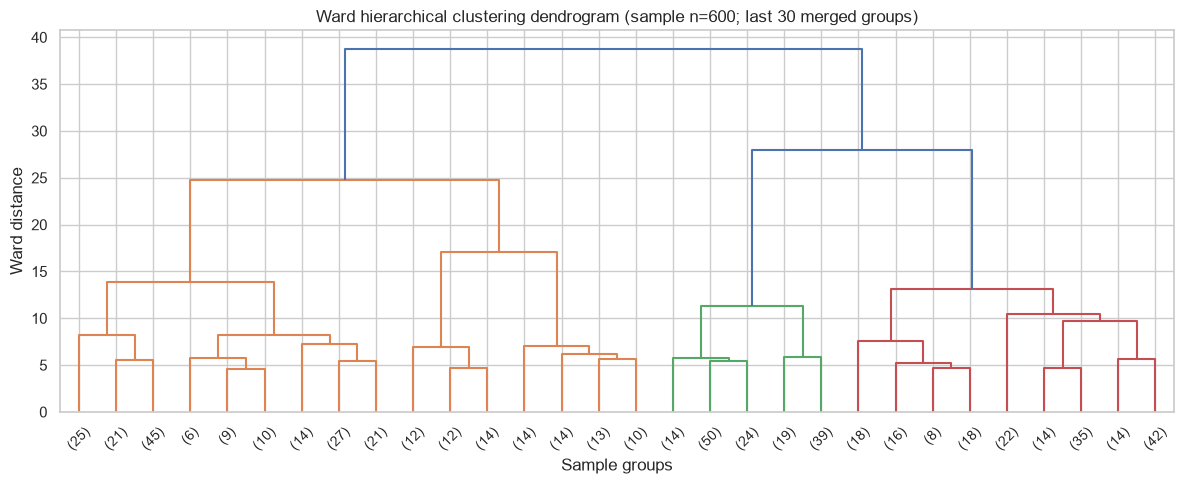

Ward silhouette on the same 600-restaurant sample (k=4): 0.246


In [4]:
# Ward hierarchical clustering on a reproducible sample; the dendrogram is truncated for readability.
sample_n = min(600, len(X_scaled))
sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_scaled), sample_n, replace=False)
ward_linkage = linkage(X_scaled[sample_idx], method="ward")
plt.figure(figsize=(12, 5))
dendrogram(ward_linkage, truncate_mode="lastp", p=30, show_leaf_counts=True)
plt.title(f"Ward hierarchical clustering dendrogram (sample n={sample_n}; last 30 merged groups)")
plt.xlabel("Sample groups")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()
ward = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
ward_labels = ward.fit_predict(X_scaled[sample_idx])
ward_silhouette = silhouette_score(X_scaled[sample_idx], ward_labels)
print(f"Ward silhouette on the same {sample_n}-restaurant sample (k={best_k}): {ward_silhouette:.3f}")

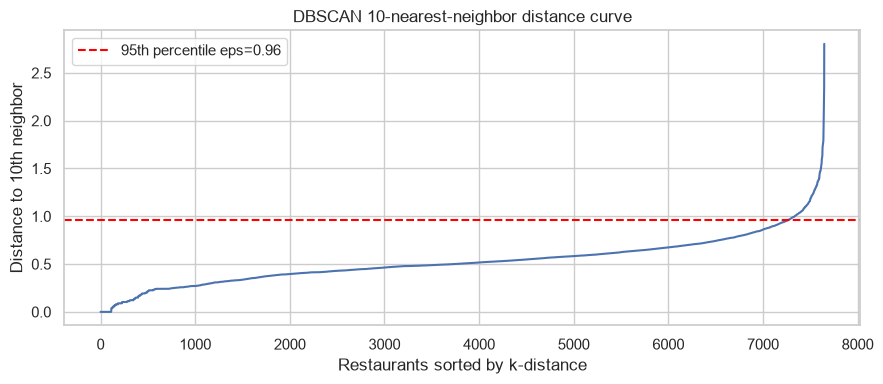

DBSCAN: eps=0.962, min_samples=10, clusters=1, noise/outliers=127 (1.7%)


In [5]:
# DBSCAN's epsilon is estimated from the 10th-neighbor distance curve; inspect the bend before interpreting noise.
min_samples = 10
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])
eps = float(np.quantile(k_distances, 0.95))
plt.figure(figsize=(9, 4))
plt.plot(k_distances)
plt.axhline(eps, color="red", linestyle="--", label=f"95th percentile eps={eps:.2f}")
plt.title("DBSCAN 10-nearest-neighbor distance curve")
plt.xlabel("Restaurants sorted by k-distance")
plt.ylabel("Distance to 10th neighbor")
plt.legend()
plt.tight_layout()
plt.show()
dbscan_labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
noise_count = int((dbscan_labels == -1).sum())
dbscan_clusters = len(set(dbscan_labels) - {-1})
print(f"DBSCAN: eps={eps:.3f}, min_samples={min_samples}, clusters={dbscan_clusters}, noise/outliers={noise_count:,} ({noise_count / len(data):.1%})")

,components,BIC
0,2,97421.516285
1,3,74138.456313
2,4,71559.904446
3,5,70147.934226
4,6,68877.625713
5,7,68205.200443
6,8,67968.846217
7,9,67422.253439
8,10,66839.926230


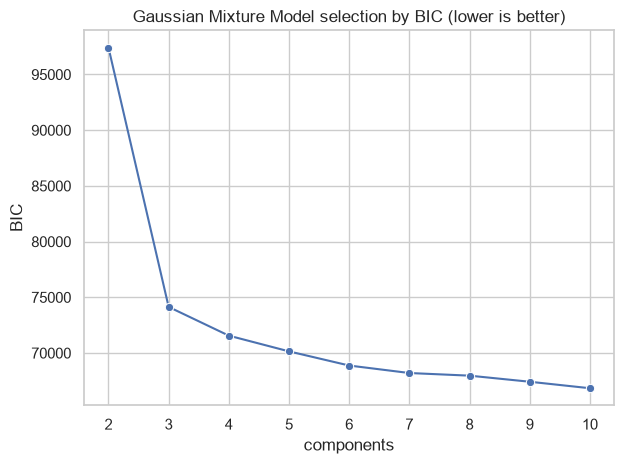

Lowest BIC: 10.0 components (66,839.9); K-Means remains the saved hard-segmentation output.


In [6]:
# A diagonal-covariance GMM keeps model selection practical while retaining a probabilistic mixture model.
component_values = range(2, 11)
gmm_models = []
bics = []
for components in component_values:
    model = GaussianMixture(n_components=components, covariance_type="diag", random_state=RANDOM_STATE, n_init=2, max_iter=200)
    model.fit(X_scaled)
    gmm_models.append(model)
    bics.append(model.bic(X_scaled))
gmm_results = pd.DataFrame({"components": list(component_values), "BIC": bics})
display(gmm_results)
sns.lineplot(data=gmm_results, x="components", y="BIC", marker="o")
plt.title("Gaussian Mixture Model selection by BIC (lower is better)")
plt.tight_layout()
plt.show()
best_gmm_idx = int(np.argmin(bics))
print(f"Lowest BIC: {gmm_results.iloc[best_gmm_idx]['components']} components ({bics[best_gmm_idx]:,.1f}); K-Means remains the saved hard-segmentation output.")

## Summary and findings

K-Means chooses k using both the elbow curve and sampled silhouette; business labels summarize observed cluster profiles and are not causal claims. Ward is a sample-based comparison, DBSCAN's noise points are density outliers, and GMM uses BIC for model selection. The saved cluster ID and name can be joined by restaurant URL in the API.

In [7]:
print(f"Final K-Means: elbow k={best_k}; silhouette={k_metrics.loc[k_metrics['k'] == best_k, 'silhouette'].iloc[0]:.3f} (silhouette-optimal k={silhouette_k}); PCA two-component variance={pca.explained_variance_ratio_.sum():.1%}.")
print(f"Segments saved: {len(profile)}; largest segment: {profile['cluster_name'].iloc[profile['size'].argmax()]} ({profile['size'].max():,} restaurants).")
print(f"Comparisons: Ward sample silhouette={ward_silhouette:.3f}; DBSCAN={dbscan_clusters} clusters / {noise_count:,} noise points; GMM best BIC has {gmm_results.iloc[best_gmm_idx]['components']} components.")
print("Limitation: clustering is sensitive to the chosen variables, scaling, k, and this dataset's review/amenity coverage; it is descriptive, not a validated customer segmentation.")

Final K-Means: elbow k=4; silhouette=0.267 (silhouette-optimal k=2); PCA two-component variance=69.4%.
Segments saved: 4; largest segment: Low-volume neighborhood venues (2,710 restaurants).
Comparisons: Ward sample silhouette=0.246; DBSCAN=1 clusters / 127 noise points; GMM best BIC has 10.0 components.
Limitation: clustering is sensitive to the chosen variables, scaling, k, and this dataset's review/amenity coverage; it is descriptive, not a validated customer segmentation.
